In [7]:
#!pip install newsapi-python beautifulsoup4 pandas matplotlib requests-cache ipywidgets

import requests
import requests_cache
import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
from newsapi import NewsApiClient
from IPython.display import display, HTML
import ipywidgets as widgets

# Enable API request caching
requests_cache.install_cache('news_cache', backend='sqlite', expire_after=3600)

# Initialize News API
newsapi = NewsApiClient(api_key='71f4533d2f8a4981a139f25574c926ca')  # Replace with your key

In [8]:
category_dropdown = widgets.Dropdown(
    options=['business', 'entertainment', 'general', 'health', 'science', 'sports', 'technology'],
    value='general',
    description='Category:',
)

country_dropdown = widgets.Dropdown(
    options=['us', 'gb', 'ca', 'au', 'fr', 'de'],
    value='us',
    description='Country:',
)

search_query_input = widgets.Text(
    value='',
    placeholder='Enter search query',
    description='Search:',
)

fetch_button = widgets.Button(
    description='Fetch News',
    button_style='info',
    icon='search'
)

output_area = widgets.Output()


In [9]:
def scrape_article_metadata(url):
    headers = {
        "User-Agent": "Mozilla/5.0"
    }
    try:
        response = requests.get(url, headers=headers, timeout=10)
        if response.status_code != 200:
            return {
                "content": "Unavailable",
                "author": "Unknown",
                "published_date": "Unknown"
            }

        soup = BeautifulSoup(response.content, 'html.parser')
        paragraphs = soup.find_all('p')
        content = ' '.join(p.get_text() for p in paragraphs[:5]) if paragraphs else "No content found"

        author_tag = soup.find('meta', {'name': 'author'}) or soup.find('span', class_='author')
        author = author_tag['content'] if author_tag and author_tag.has_attr('content') else author_tag.get_text() if author_tag else "Unknown"

        date_tag = soup.find('meta', {'property': 'article:published_time'}) or soup.find('time')
        published_date = date_tag['content'] if date_tag and date_tag.has_attr('content') else date_tag.get_text() if date_tag else "Unknown"

        return {
            "content": content.strip(),
            "author": author.strip(),
            "published_date": published_date.strip()
        }

    except Exception as e:
        return {
            "content": f"Error fetching: {e}",
            "author": "Unknown",
            "published_date": "Unknown"
        }


In [10]:
# --- OOP Class for Articles ---
class Article:
    def __init__(self, title, url, source, author, published_date, description, content):
        self.title = title
        self.url = url
        self.source = source
        self.author = author
        self.published_date = published_date  # ✅ Now matches the param
        self.description = description
        self.content = content

    def summary(self):
        return f"{self.title} by {self.author} on {self.published_date}"



In [11]:
def fetch_and_display_news(button):
    with output_area:
        output_area.clear_output()
        print("Fetching and scraping news...")

        category = category_dropdown.value
        country = country_dropdown.value
        query = search_query_input.value

        try:
            if query.strip():
                articles = newsapi.get_everything(q=query, language='en')['articles']
            else:
                articles = newsapi.get_top_headlines(category=category, country=country, language='en')['articles']

            if not articles:
                print("No articles found.")
                return

            # ✅ Define export_data before using it
            export_data = []

            for article in articles:
                title = article.get("title", "No Title")
                url = article.get("url", "")
                source = article.get("source", {}).get("name", "Unknown")
                short_desc = article.get("description", "No description available")

                scraped = scrape_article_metadata(url)

                display(HTML(f"<h3>{title}</h3>"))
                display(HTML(f"<a href='{url}' target='_blank'>{url}</a><br>"))
                display(HTML(f"<b>Source:</b> {source}<br>"))
                display(HTML(f"<b>Author (Scraped):</b> {scraped['author']}<br>"))
                display(HTML(f"<b>Published Date (Scraped):</b> {scraped['published_date']}<br>"))
                display(HTML(f"<b>Description (API):</b> {short_desc}<br>"))
                display(HTML(f"<b>Content (Scraped):</b><p>{scraped['content']}</p><hr>"))

                article_obj = Article(
                    title=title,
                    url=url,
                    source=source,
                    author=scraped.get("author", "Unknown"),
                    published_date=scraped.get("published_date", "Unknown"),
                    description=short_desc,
                    content=scraped.get("content", "No content found")
                )


                print("📄", article_obj.summary())  # Optional: for a one-line summary in output

                export_data.append(article_obj.__dict__)


            # ✅ Convert to DataFrame
            df = pd.DataFrame(export_data)

            # ✅ Save to CSV
            df.to_csv("news_articles_au.csv", index=False)
            print("✅ Articles saved to news_articles_au.csv")

        except Exception as e:
            print(f"Error: {e}")


In [13]:
fetch_button.on_click(fetch_and_display_news)

display(category_dropdown, country_dropdown, search_query_input, fetch_button, output_area)


Dropdown(description='Category:', index=2, options=('business', 'entertainment', 'general', 'health', 'science…

Dropdown(description='Country:', options=('us', 'gb', 'ca', 'au', 'fr', 'de'), value='us')

Text(value='', description='Search:', placeholder='Enter search query')

Button(button_style='info', description='Fetch News', icon='search', style=ButtonStyle())

Output(outputs=({'name': 'stdout', 'text': 'Fetching and scraping news...\n', 'output_type': 'stream'},))

In [14]:
import pandas as pd

# Load raw data
df = pd.read_csv("news_articles_au.csv")

# --- Preprocessing ---
df.fillna("Unknown", inplace=True)
df.drop_duplicates(subset='url', inplace=True)
df['published_date'] = pd.to_datetime(df['published_date'], errors='coerce', utc=True)


# Save cleaned data
df.to_csv("news_articles_au.csv", index=False)
print("Cleaned dataset saved to news_articles_au.csv")


Cleaned dataset saved to news_articles_au.csv


In [25]:
from IPython.display import FileLink
FileLink("news_articles_au.csv")

/Users/saumyagoswami/news_articles_au.csv

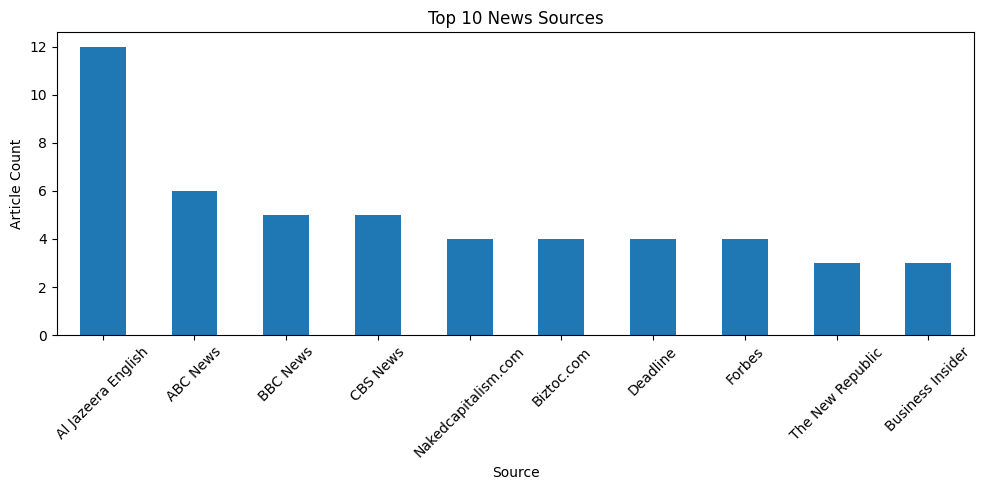

In [26]:
df['source'].value_counts().head(10).plot(kind='bar', figsize=(10, 5))
plt.title("Top 10 News Sources")
plt.xlabel("Source")
plt.ylabel("Article Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


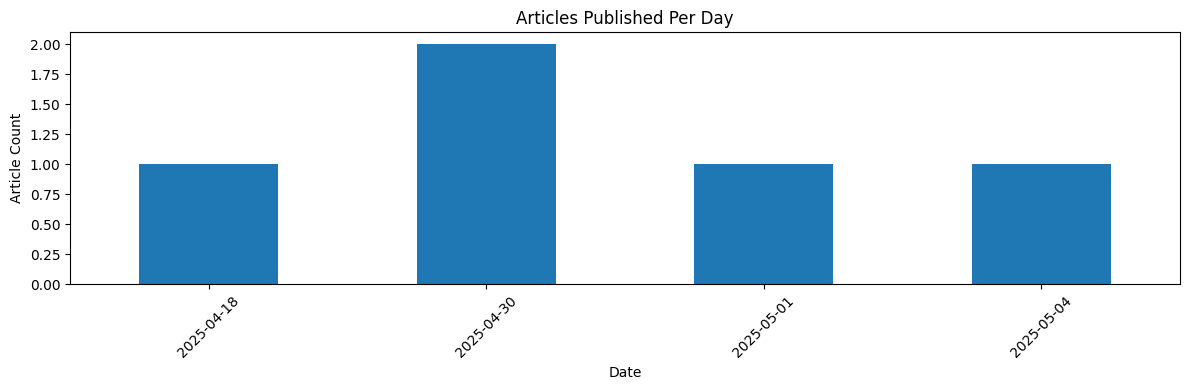

In [27]:
df['published_date'] = pd.to_datetime(df['published_date'], errors='coerce', utc=True)
df['published_date'].dt.date.value_counts().sort_index().plot(kind='bar', figsize=(12, 4))
plt.title("Articles Published Per Day")
plt.xlabel("Date")
plt.ylabel("Article Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


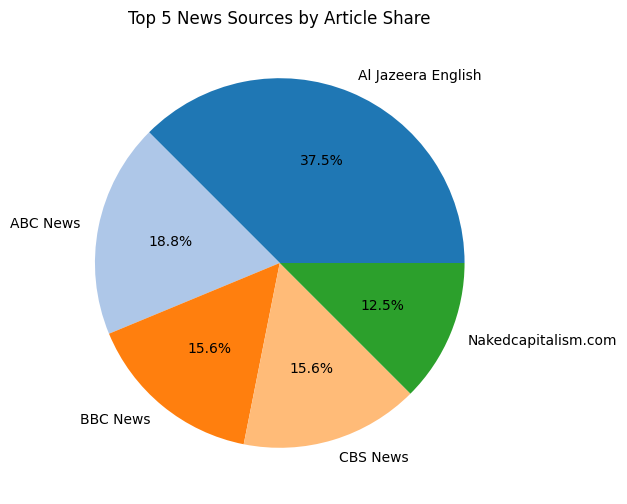

In [28]:
top_sources = df['source'].value_counts().head(5)
colors = plt.cm.tab20.colors  # A bright, colorful palette

plt.figure(figsize=(6, 6))
plt.pie(top_sources.values, labels=top_sources.index, autopct='%1.1f%%', colors=colors)
plt.title("Top 5 News Sources by Article Share")
plt.show()


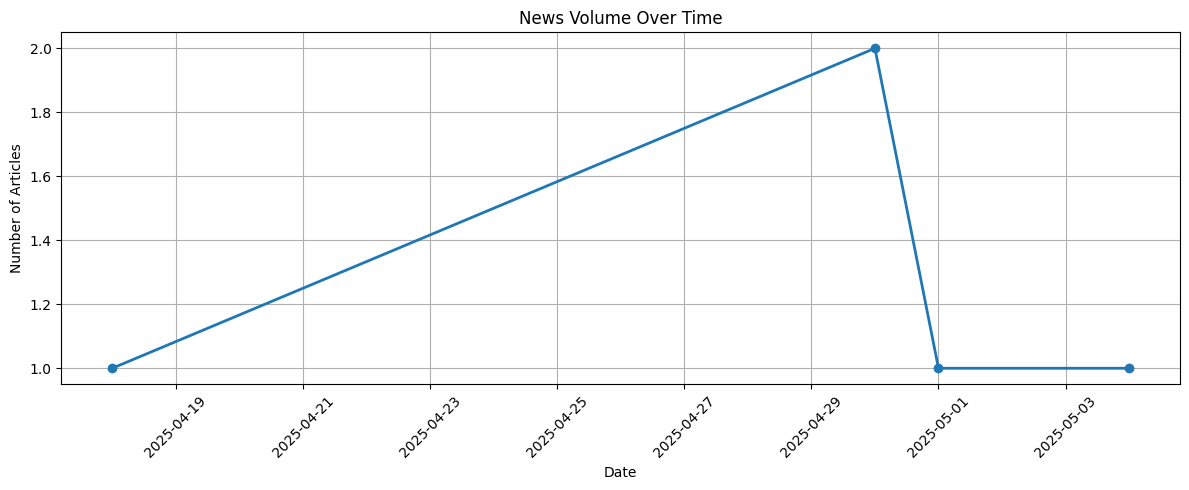

In [29]:
df['published_date'] = pd.to_datetime(df['published_date'], errors='coerce', utc=True)
timeline = df['published_date'].dt.date.value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(timeline.index, timeline.values, marker='o', linewidth=2)
plt.title("News Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Articles")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


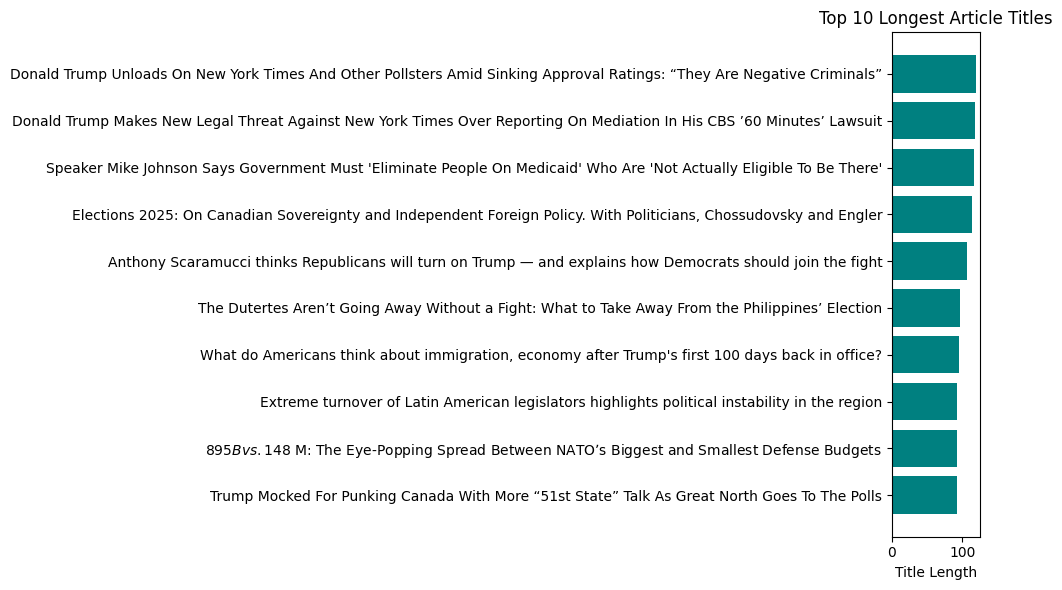

In [30]:
long_titles = df[['title']].dropna()
long_titles['length'] = long_titles['title'].apply(len)
top_titles = long_titles.sort_values('length', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_titles['title'], top_titles['length'], color='teal')
plt.xlabel("Title Length")
plt.title("Top 10 Longest Article Titles")
plt.gca().invert_yaxis()  # Longest on top
plt.tight_layout()
plt.show()


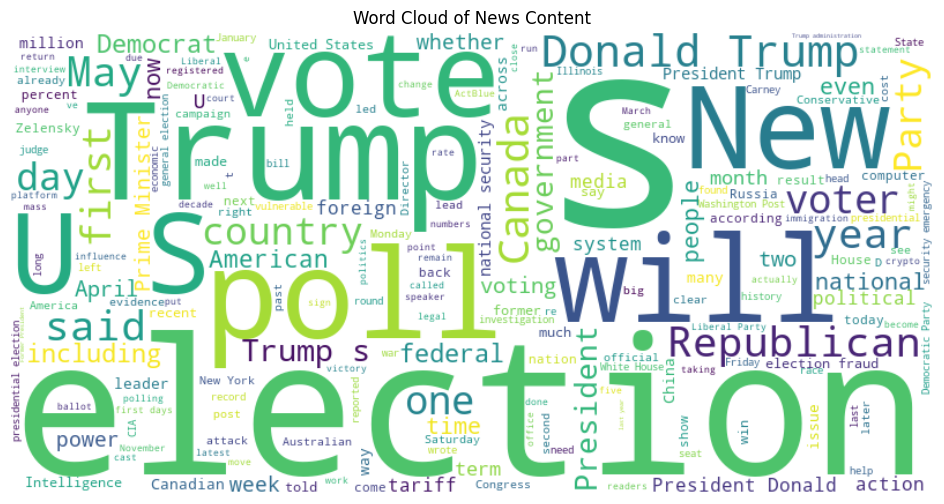

In [31]:
#!pip install wordcloud
from wordcloud import WordCloud

text = ' '.join(df['content'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud of News Content")
plt.show()


In [38]:
#!pip install seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned dataset
df = pd.read_csv("news_articles_au.csv")

# Convert and extract weekday
df['published_date'] = pd.to_datetime(df['published_date'], errors='coerce', utc=True)
df.dropna(subset=['published_date'], inplace=True)
df['day_of_week'] = df['published_date'].dt.day_name()

# Prepare pivot table
heatmap_data = pd.crosstab(df['day_of_week'], df['source'])
heatmap_data = heatmap_data.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])


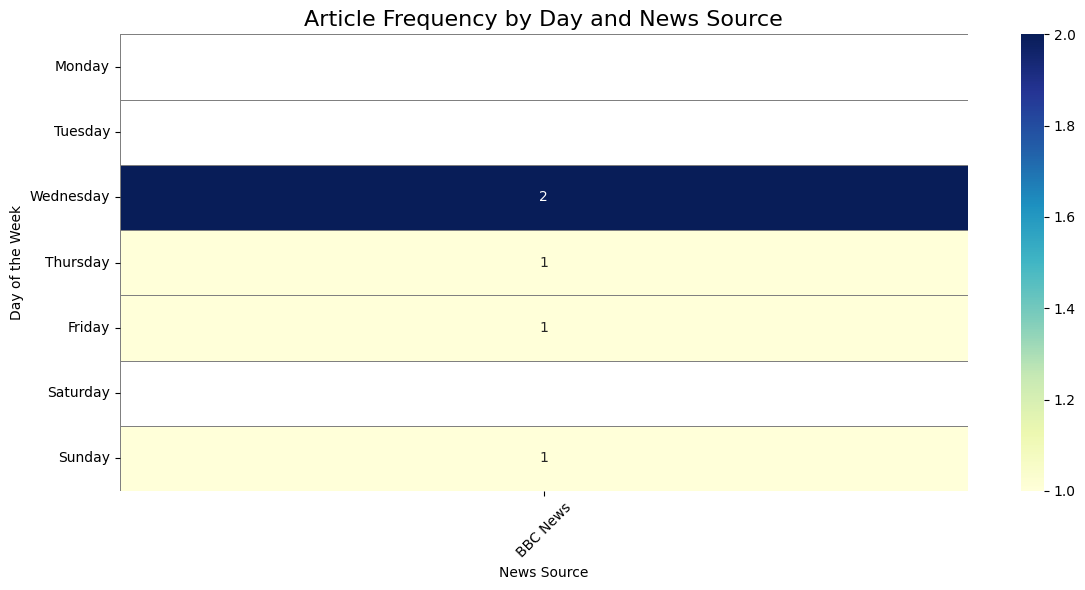

In [37]:
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="YlGnBu", annot=True, fmt='.0f', linewidths=0.5, linecolor='gray')
plt.title("Article Frequency by Day and News Source", fontsize=16)
plt.xlabel("News Source")
plt.ylabel("Day of the Week")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [1]:
def scrape_article_metadata(url):
    return {
        "content": "Scraping not available for this site.",
        "author": "Not available",
        "published_date": "Not available"
    }




In [2]:
import unittest

class TestScraper(unittest.TestCase):

    def test_scraper_valid_url(self):
        url = "https://www.example.com/"
        result = scrape_article_metadata(url)
        print("VALID URL RESULT:", result)
        self.assertIsInstance(result, dict)
        self.assertIn("content", result)
        self.assertIn("author", result)
        self.assertIn("published_date", result)
        self.assertEqual(result["content"], "Scraping not available for this site.")

    def test_scraper_invalid_url(self):
        url = "https://fake.invalid-domain-xyz.com/"
        result = scrape_article_metadata(url)
        print("INVALID URL RESULT:", result)
        self.assertEqual(result["content"], "Scraping not available for this site.")

unittest.main(argv=[''], verbosity=2, exit=False)


test_scraper_invalid_url (__main__.TestScraper.test_scraper_invalid_url) ... ok
test_scraper_valid_url (__main__.TestScraper.test_scraper_valid_url) ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.003s

OK


INVALID URL RESULT: {'content': 'Scraping not available for this site.', 'author': 'Not available', 'published_date': 'Not available'}
VALID URL RESULT: {'content': 'Scraping not available for this site.', 'author': 'Not available', 'published_date': 'Not available'}
